1. Analyze and Preprocess data - Check if the dataset has missing values or has any other problem.
2. Feature Engineering
3. Divide the dataset into 2 training and test sets
4. Use Pipeline\
    4. a. Use scaler and dimensional reduction (if it is necessary).\
    4. b. Use suitable Naive Bayes for this problem.
5. Perform model on training set and test set using gridsearch CV
6. Measure performance of the model.
7. Which metric is your main metric for this problem and why? What are your scaler, dimensional reduction and naive bayes model as well as their params? (<= 200 words, also input your opinion or conclusion here)


How can I measure your point:
1. Your function is callable and runs correctly
2. The performance of your model (in full pipeline) is acceptable. The final error based on my train and test set is low enough.
3. The data preprocessing is correct or make sense
4. The Feature engineering is correct or make sense
5. Any other additional process will be considered a small plus point.

A Travel Company Is Offering Travel Insurance Packages To Their Customers. The new insurance plan also covers Covid-19. The Company Claims To Know Which Customers Are Interested To Buy It Based On The Company's Database History.

* Age - Age Of The Customer
* Employment Type - The Sector In Which Customer Is Employed
GraduateOrNot - Whether The Customer Is College Graduate Or Not
* AnnualIncome - The Yearly Income Of The Customer In Indian Rupees
* FamilyMembers - Number Of Members In Customer's Family
* ChronicDisease - Whether The Customer Suffers From Any Major Disease Or Conditions Like Diabetes/High BP or Asthama,etc.
* FrequentFlyer - Derived Data Based On Customer's History Of Booking Air Tickets On Atleast 4 Different Instances In The Last 2 Years (2017-2019).
* EverTravelledAbroad - Has The Customer Ever Travelled To A Foreign Country
* TravelInsurance - Did The Customer Buy Travel Insurance Package During Introductory Offering Held In The Year 2019.

**Submit Link**: https://forms.gle/CwmpBrfa2SYQic7G6

## Load Dataset

In [141]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [142]:
import pandas as pd

df = pd.read_csv(r"D:\ML\tuan3\TravelInsurancePrediction.csv")
df.head()

,Unnamed: 0,Age,Employment Type,GraduateOrNot,AnnualIncome,FamilyMembers,ChronicDiseases,FrequentFlyer,EverTravelledAbroad,TravelInsurance
0,0,31,Government Sector,Yes,400000,6,1,No,No,0
1,1,31,Private Sector/Self Employed,Yes,1250000,7,0,No,No,0
2,2,34,Private Sector/Self Employed,Yes,500000,4,1,No,No,1
3,3,28,Private Sector/Self Employed,Yes,700000,3,1,No,No,0
4,4,28,Private Sector/Self Employed,Yes,700000,8,1,Yes,No,0


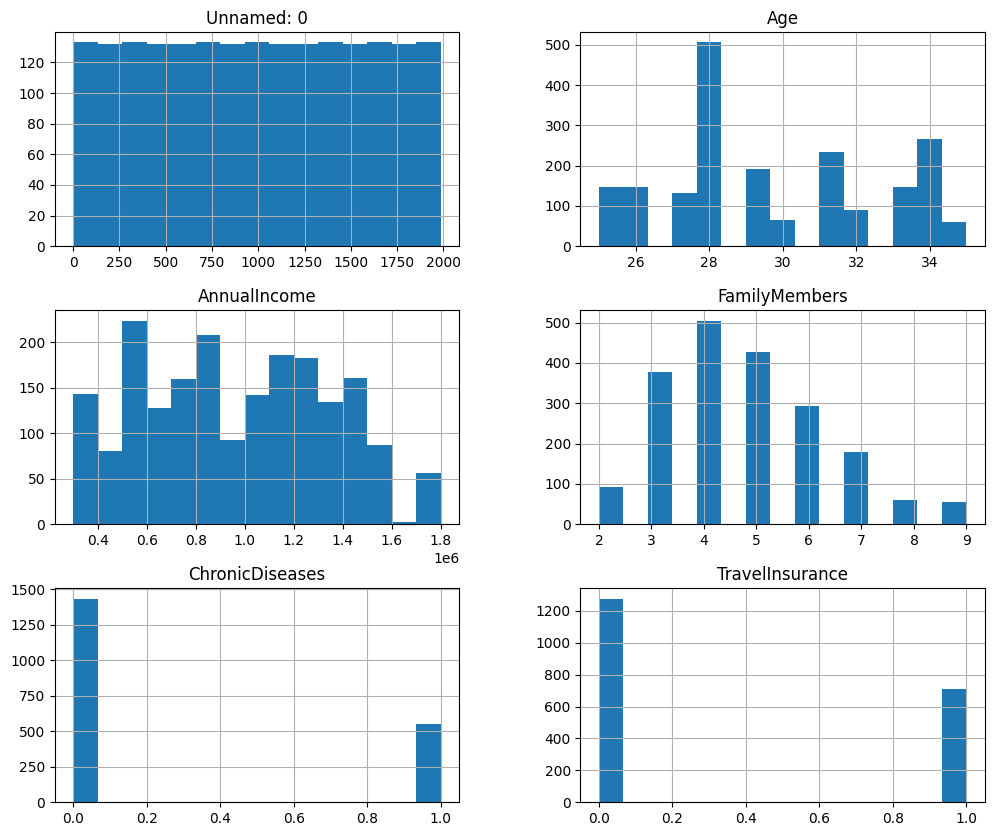

In [143]:
#ToDo: Show histogram of dataframe
df.hist(df.columns, figsize=(12, 10), bins=15)
plt.show()

## Data Analysis

In [144]:
# Data analysis
# Todo: analyze your data here
# Get categorical columns and numerical columns
categorical_cols = [feature for feature in df.columns if df[feature].dtype == "O"]
numerical_cols   = [feature for feature in df.columns if df[feature].dtype != "O" and feature != "User ID"]
print(categorical_cols)
print(numerical_cols)

['Employment Type', 'GraduateOrNot', 'FrequentFlyer', 'EverTravelledAbroad']
['Unnamed: 0', 'Age', 'AnnualIncome', 'FamilyMembers', 'ChronicDiseases', 'TravelInsurance']


In [145]:
# Check Missing values
print(df[categorical_cols].isnull().sum())
print(df[numerical_cols].isnull().sum())

Employment Type        0
GraduateOrNot          0
FrequentFlyer          0
EverTravelledAbroad    0
dtype: int64
Unnamed: 0         0
Age                0
AnnualIncome       0
FamilyMembers      0
ChronicDiseases    0
TravelInsurance    0
dtype: int64


C:\Users\quanp\AppData\Local\Temp\ipykernel_11392\2116375380.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\quanp\AppData\Local\Temp\ipykernel_11392\2116375380.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\quanp\AppData\Local\Temp\ipykernel_11392\2116375380.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\quanp\AppData\Local\Temp\ipykernel_11392\2116375380.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `h

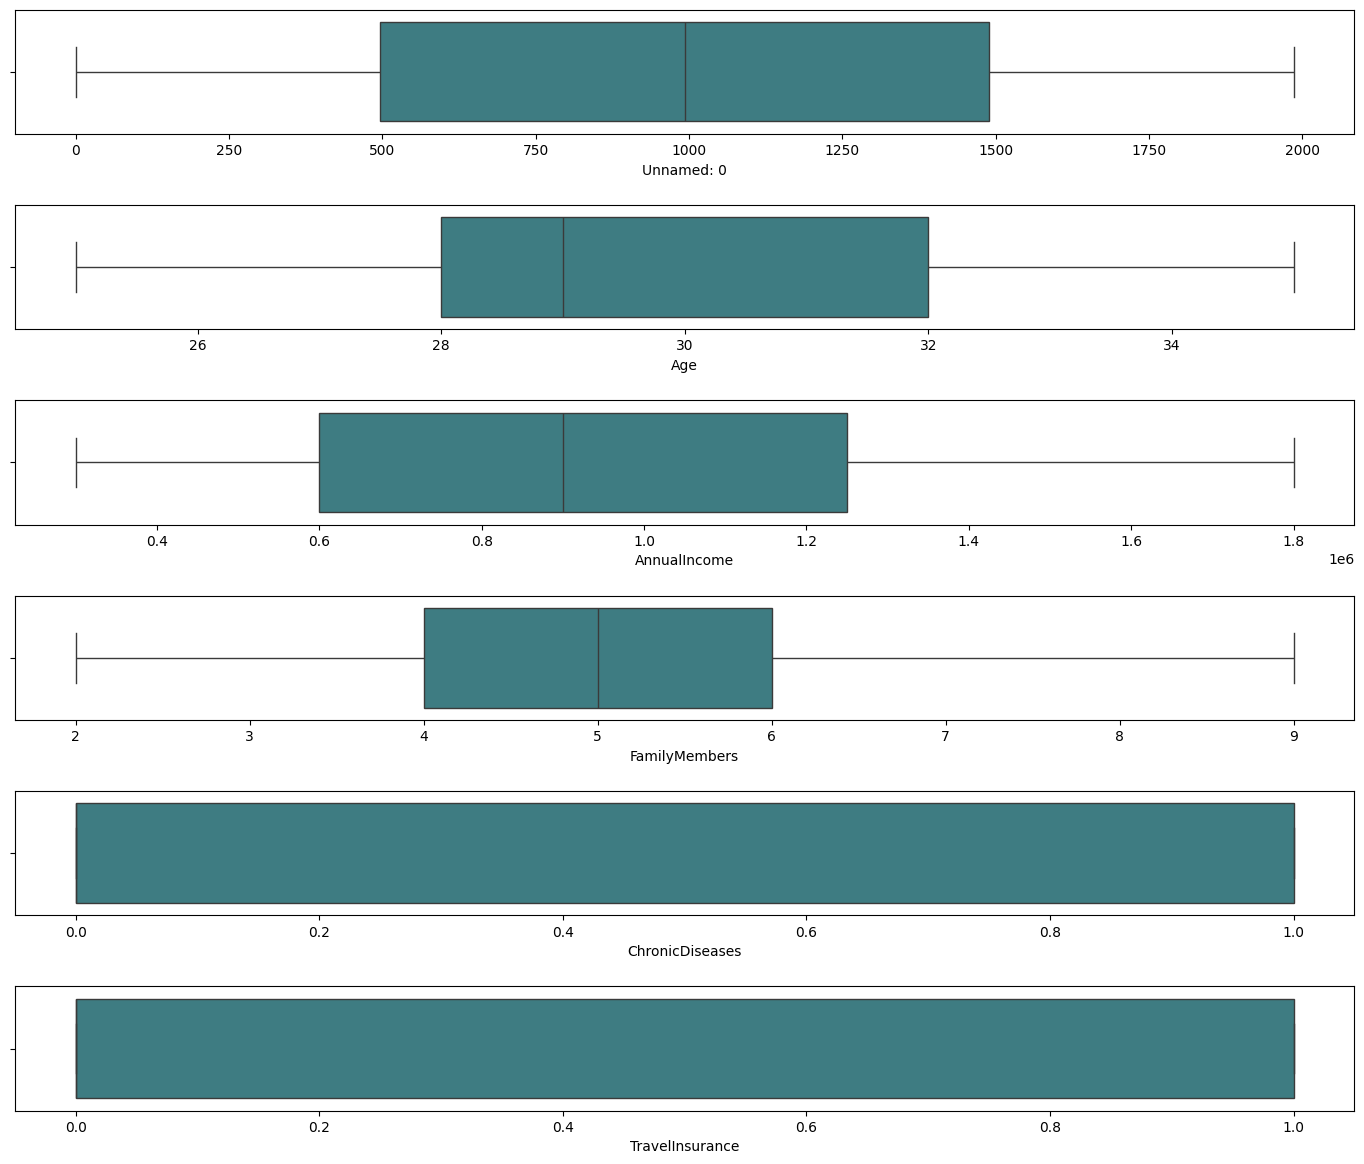

In [146]:
# Tạo nhiều subplot (nhiều biểu đồ con)
# len(numerical_cols): số lượng hàng (mỗi biến số 1 hàng)
# 1: số cột (mỗi hàng chỉ có 1 biểu đồ)
# figsize: kích thước toàn bộ figure (chiều rộng 14, chiều cao tỷ lệ theo số biến)
# sharex=False, sharey=False: các trục không dùng chung scale
fig, axes = plt.subplots(
    len(numerical_cols),
    1,
    figsize=(14, 2 * len(numerical_cols)),
    sharex=False,
    sharey=False
)

# Duyệt qua từng cột số
# enumerate giúp lấy cả index (i) và tên cột (column)
for i, column in enumerate(numerical_cols):

    # Vẽ boxplot cho từng cột
    # x=column: giá trị của cột đó nằm trên trục x
    # data=df: dữ liệu lấy từ dataframe df
    # palette='crest': chọn bảng màu
    # ax=axes[i]: vẽ vào subplot thứ i
    sns.boxplot(
        x=column,
        data=df,
        palette='crest',
        ax=axes[i]
    )

# Tự động căn chỉnh khoảng cách giữa các subplot cho gọn
# pad=2.0: tăng khoảng cách giữa các biểu đồ
plt.tight_layout(pad=2.0)

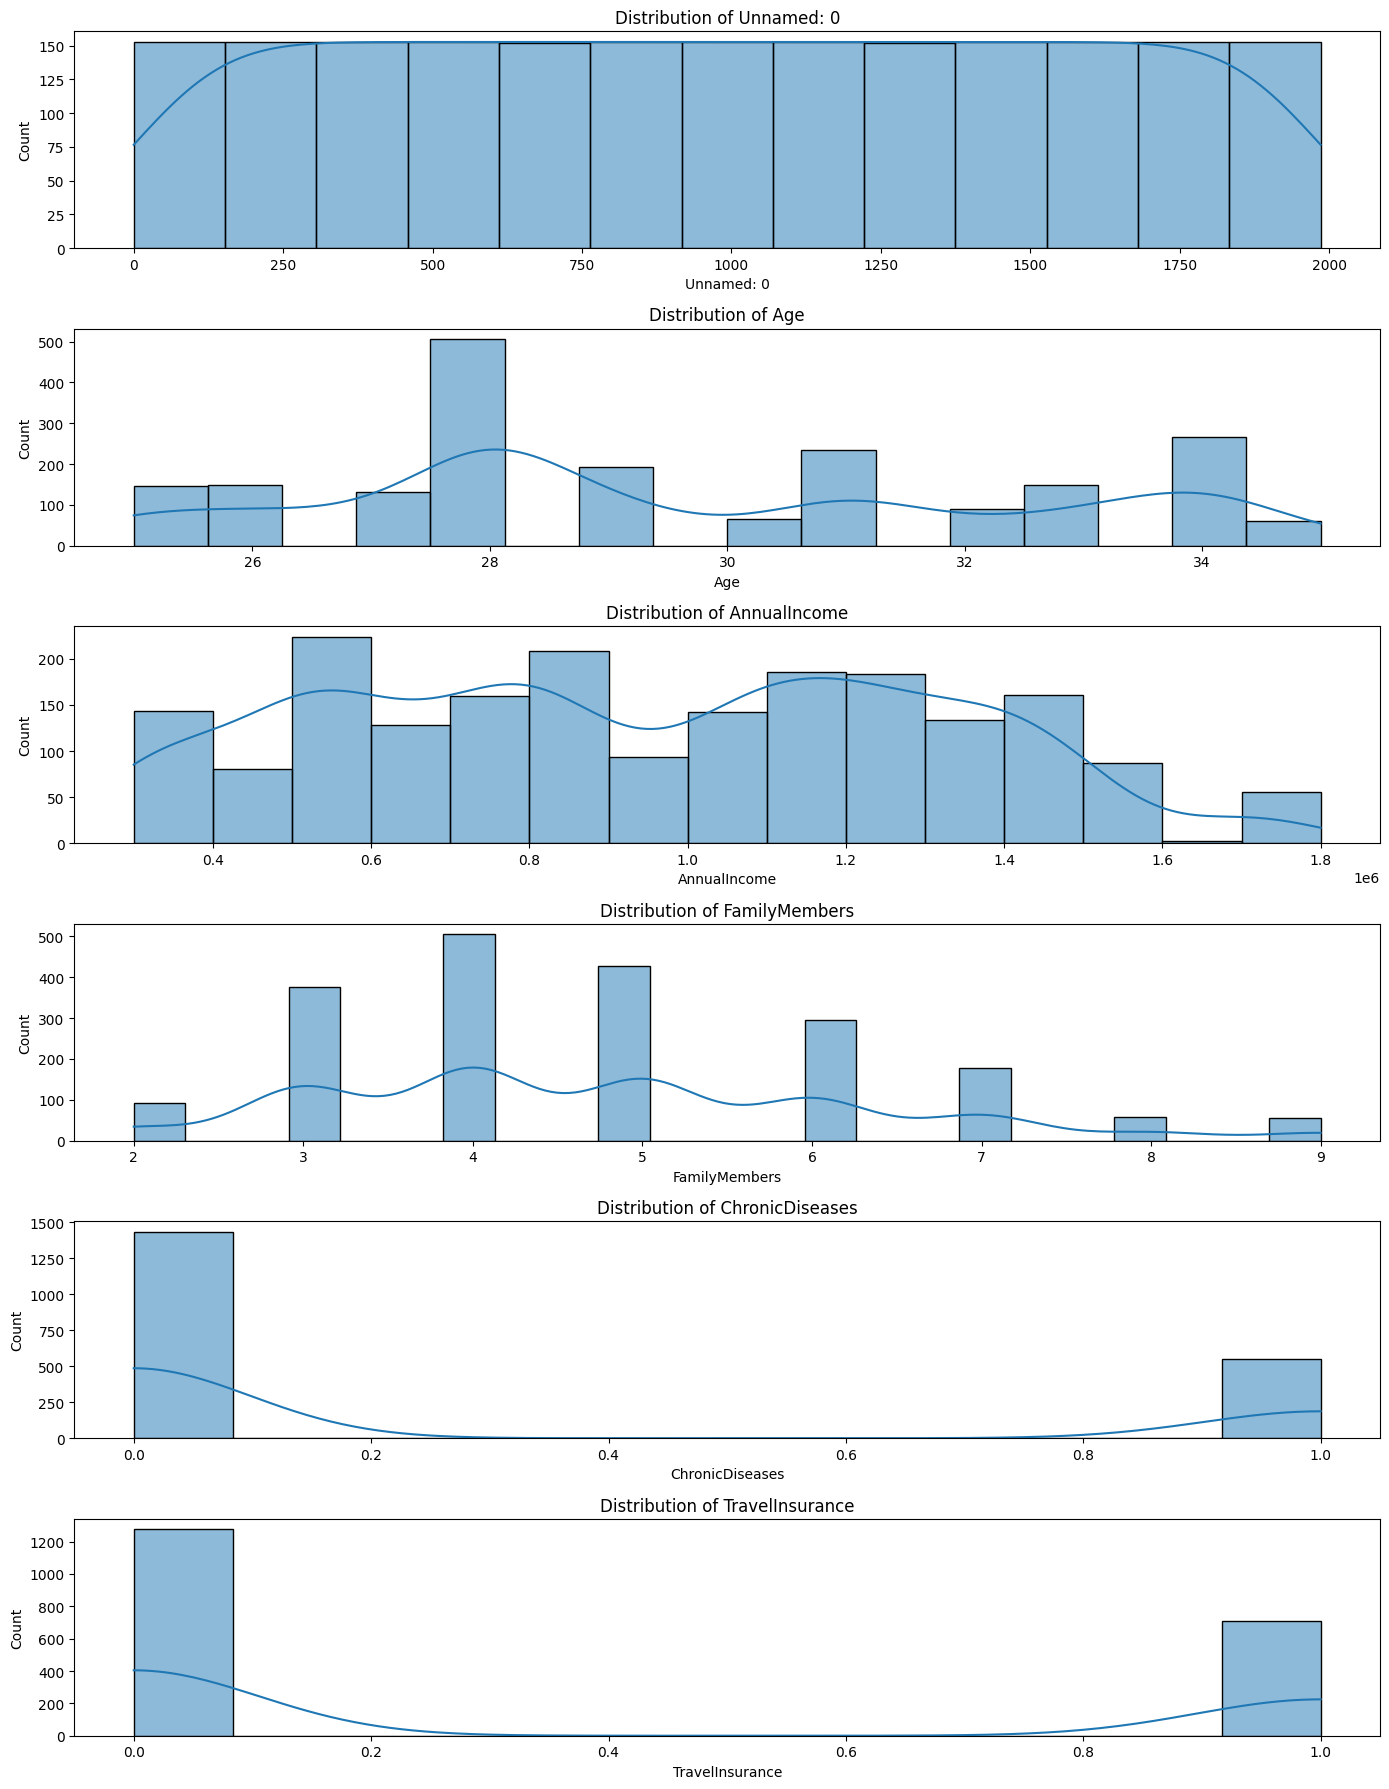

In [147]:
fig, axes = plt.subplots(len(numerical_cols), 1, figsize=(14, 3*len(numerical_cols)))

for i, col in enumerate(numerical_cols):
    # Vẽ histogram để xem phân phối dữ liệu
    # kde=True: thêm đường mật độ (density curve) để nhìn xu hướng mượt hơn
    sns.histplot(df[col], kde=True, ax=axes[i])

    # Đặt tiêu đề cho từng subplot
    axes[i].set_title(f"Distribution of {col}")

# Tự động căn chỉnh layout để không bị chồng lấn
plt.tight_layout()

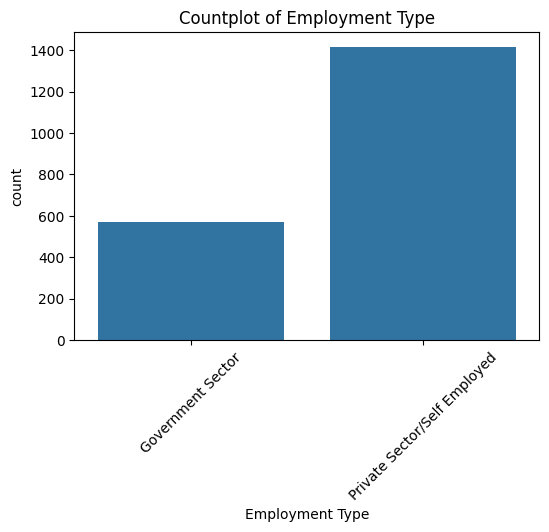

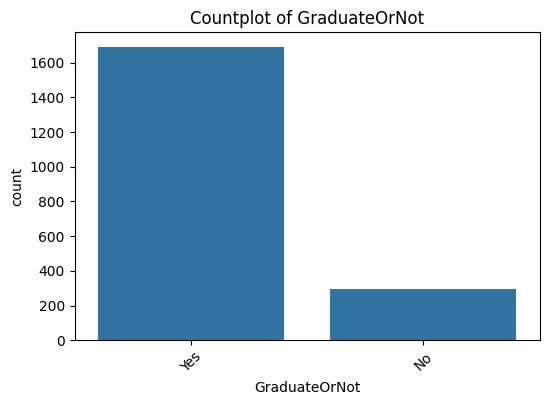

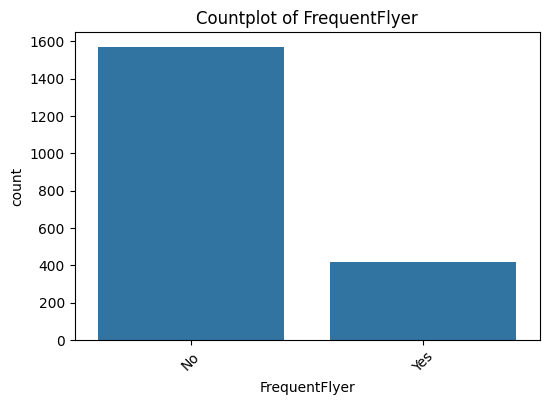

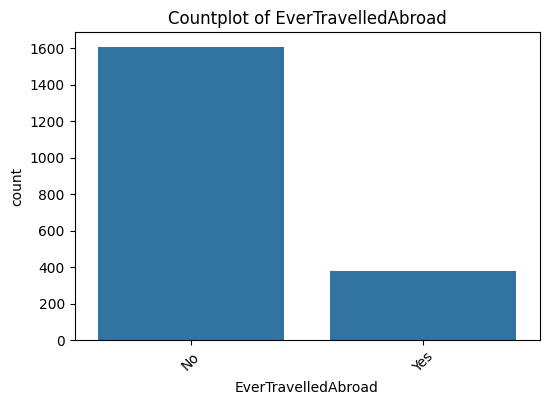

In [148]:
for col in categorical_cols:
    plt.figure(figsize=(6,4))

    # Countplot đếm số lượng từng category
    sns.countplot(x=col, data=df)

    # Tiêu đề biểu đồ
    plt.title(f"Countplot of {col}")

    # Xoay label nếu bị chồng
    plt.xticks(rotation=45)

    plt.show()

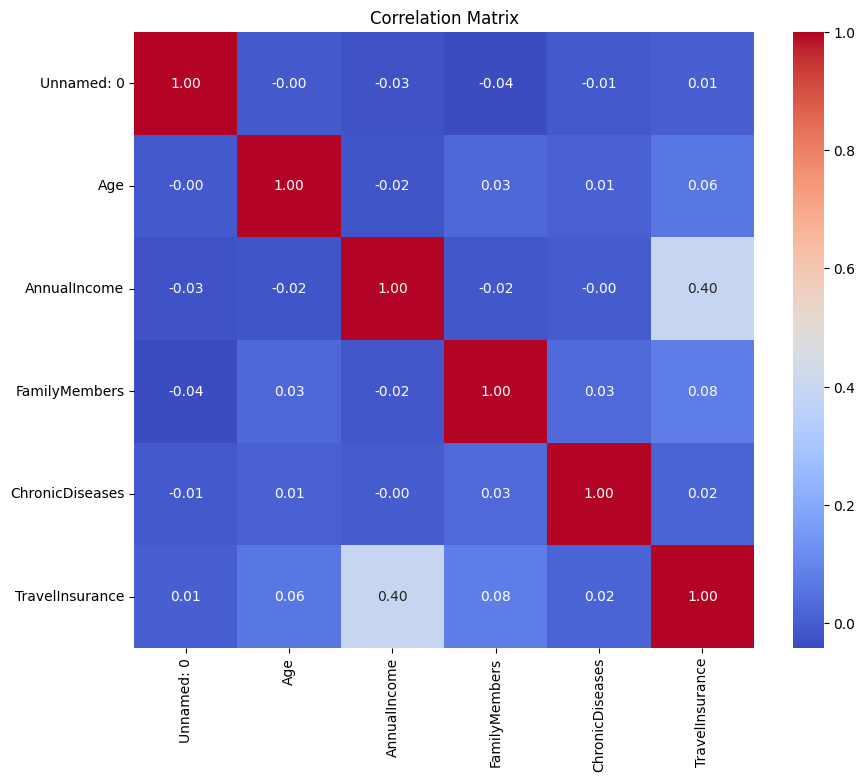

In [149]:
plt.figure(figsize=(10,8))

# Tính ma trận tương quan giữa các biến số
corr = df[numerical_cols].corr()

# Heatmap để visualize tương quan
# annot=True: hiển thị giá trị
# cmap='coolwarm': chọn màu
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")

plt.title("Correlation Matrix")
plt.show()

<Axes: xlabel='TravelInsurance', ylabel='Count'>

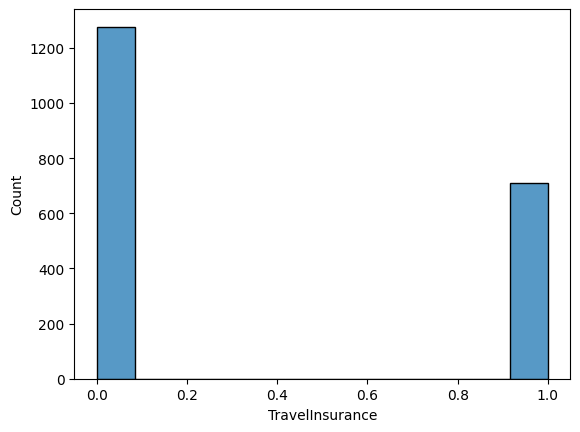

In [150]:
#Xem phân phối của EstimatedSalary
sns.histplot(x='TravelInsurance', data=df)

## Preprocessing

In [151]:
def preprocessing_data(df):
    """
    Preprocess your data (eg. Drop null datapoints or fill missing data)
    :param df: pandas DataFrame
    :return: pandas DataFrame
    """
    # Todo: preprocess data
    df.drop('Unnamed: 0', axis=1, inplace=True)
    return df

In [152]:
df = preprocessing_data(df.copy())
df.head()

,Age,Employment Type,GraduateOrNot,AnnualIncome,FamilyMembers,ChronicDiseases,FrequentFlyer,EverTravelledAbroad,TravelInsurance
0,31,Government Sector,Yes,400000,6,1,No,No,0
1,31,Private Sector/Self Employed,Yes,1250000,7,0,No,No,0
2,34,Private Sector/Self Employed,Yes,500000,4,1,No,No,1
3,28,Private Sector/Self Employed,Yes,700000,3,1,No,No,0
4,28,Private Sector/Self Employed,Yes,700000,8,1,Yes,No,0


## Feature Engineering

<Axes: >

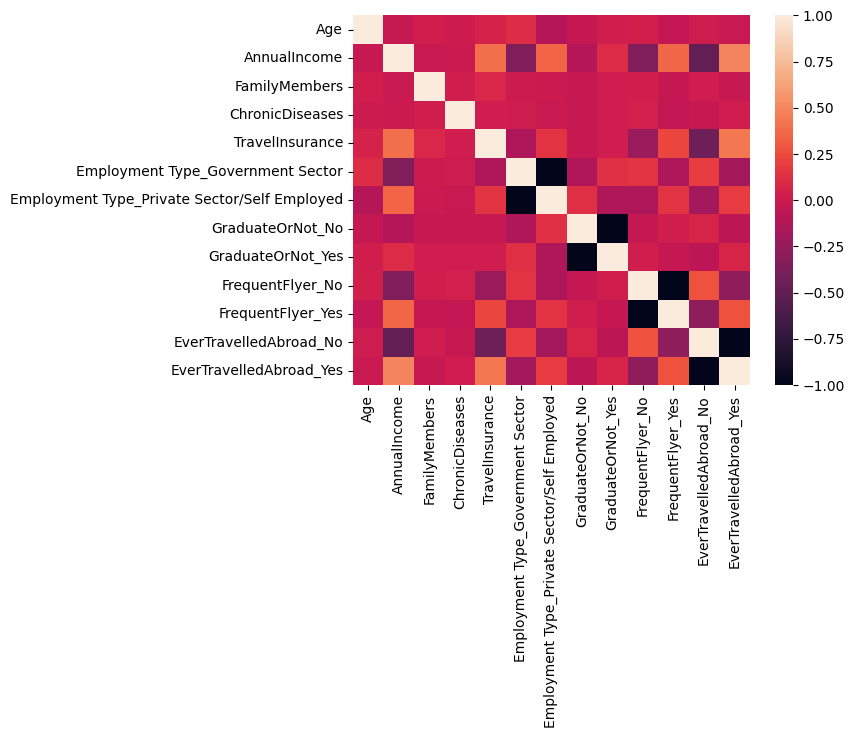

In [153]:
# Heatmap
import seaborn as sns

def apply_feature_engineering(df):
    """
    Apply all feature engineering to transform your data into number
    :param df: pandas DataFrame
    :return: pandas DataFrame
    """
    # Todo: Normalize your data
    df = pd.get_dummies(df, columns=['Employment Type', 'GraduateOrNot', 'FrequentFlyer', 'EverTravelledAbroad']).astype(int)
    return df

df = apply_feature_engineering(df)
sns.heatmap(df.corr()) # Show heatmap after normalized data

In [154]:
df.head()

,Age,AnnualIncome,FamilyMembers,ChronicDiseases,TravelInsurance,Employment Type_Government Sector,Employment Type_Private Sector/Self Employed,GraduateOrNot_No,GraduateOrNot_Yes,FrequentFlyer_No,FrequentFlyer_Yes,EverTravelledAbroad_No,EverTravelledAbroad_Yes
0,31,400000,6,1,0,1,0,0,1,1,0,1,0
1,31,1250000,7,0,0,0,1,0,1,1,0,1,0
2,34,500000,4,1,1,0,1,0,1,1,0,1,0
3,28,700000,3,1,0,0,1,0,1,1,0,1,0
4,28,700000,8,1,0,0,1,0,1,0,1,1,0


In [155]:
def prepare_X_y(df):
    """
    Feature engineering and create X and y
    :param df: pandas dataframe
    :return: (X, y) output feature matrix (dataframe), target (series)
    """
    # Todo: Split data into X and y (using sklearn train_test_split). Return two dataframes
    X = df.drop(columns=['TravelInsurance'])# Todo: Select features
    y = df['TravelInsurance']# Todo: Select label
    return X, y

X, y = prepare_X_y(df)

# Apply machine learning model

## Train-test split

In [156]:
from sklearn.model_selection import train_test_split
RANDOM_STATE = 42
TRAIN_SIZE = 0.8

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=TRAIN_SIZE, random_state=RANDOM_STATE)

## Build SK-learn model

In [160]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.pipeline import make_pipeline
from sklearn.naive_bayes import GaussianNB, BernoulliNB
from sklearn.preprocessing import Binarizer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV

def build_model_a(X, y):
    """
    Design your model and train it (including your best params)
    :param X: feature matrix
    :param y: target
    :return: a model
    """

    # Todo: Input your scaler and logistic model into pipeline
    pipeline = make_pipeline(
        StandardScaler(),
        PCA(),
        GaussianNB()
    )

    smoothing_values = np.logspace(-1, -9, num=100)
    param_grid = {
        "pca__n_components": [5, 6, 7, 8, 9, 10, 11],
        "gaussiannb__var_smoothing": smoothing_values
    }

    # Khởi tạo GridSearchCV
    # scoring='recall': Tối ưu hóa dựa trên độ chính xác 
    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        scoring='recall', 
        cv=5,
        n_jobs=-1,
    )
    
    # Todo: fit your model with X, y
    grid_search.fit(X, y)
    
    # Lấy ra mô hình tốt nhất từ quá trình tìm kiếm
    best_model = grid_search.best_estimator_
    print("Best parameter (CV score=%0.3f):" % grid_search.best_score_)
    print(grid_search.best_params_)

    return best_model

def build_model_b(X, y):
    """
    Design your model and train it (including your best params)
    :param X: feature matrix
    :param y: target
    :return: a model
    """

    # Todo: Input your scaler and logistic model into pipeline
    pipeline = make_pipeline(
        StandardScaler(),
        PCA(),
        BernoulliNB()
    )

    alpha = np.logspace(-1, -9, num=100)
    param_grid = {
        "pca__n_components": [5, 6, 7, 8, 9, 10, 11],
        "bernoullinb__alpha": alpha
    }

    # Khởi tạo GridSearchCV
    # scoring='recall': Tối ưu hóa dựa trên độ chính xác 
    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        scoring='recall', 
        cv=5,
        n_jobs=-1,
    )
    
    # Todo: fit your model with X, y
    grid_search.fit(X, y)
    
    # Lấy ra mô hình tốt nhất từ quá trình tìm kiếm
    best_model = grid_search.best_estimator_
    print("Best parameter (CV score=%0.3f):" % grid_search.best_score_)
    print(grid_search.best_params_)

    return best_model

def calculate_performance(y_true, y_pred):
    """

    :param y_true: ground truth values
    :param y_pred: predictions
    :return:
    """
    # Todo: return your error value like accuracy, f1score, ...
    print("precision", precision_score(y_true, y_pred) )
    print("recall", recall_score(y_true, y_pred))
    print("accuracy", accuracy_score(y_true, y_pred))
    print("F1", f1_score(y_true, y_pred))

    # Todo: Only choose one of them as your score for the question 7
    main_score = recall_score(y_true, y_pred)
    return main_score

In [161]:
model_a = build_model_a(X_train, y_train)
# Compare on training dataset
pred = model_a.predict(X_test)
calculate_performance(y_test, pred)

Best parameter (CV score=0.513):
{'gaussiannb__var_smoothing': np.float64(0.00021544346900318823), 'pca__n_components': 5}
precision 0.7254901960784313
recall 0.524822695035461
accuracy 0.7613065326633166
F1 0.6090534979423868


0.524822695035461

In [162]:
model_b = build_model_b(X_train, y_train)
# Compare on training dataset
pred = model_b.predict(X_test)
calculate_performance(y_test, pred)

Best parameter (CV score=0.531):
{'bernoullinb__alpha': np.float64(0.1), 'pca__n_components': 10}
precision 0.5905511811023622
recall 0.5319148936170213
accuracy 0.7035175879396985
F1 0.5597014925373134


0.5319148936170213

### 7:
**Main Metric**: My main metric is Recall. In predicting travel insurance purchases, failing to identify a potential buyer (False Negative) means a direct loss of potential revenue. Optimizing Recall ensures that our marketing efforts capture as many actual buyers as possible, which is more valuable for business growth than merely saving on marketing costs.

**Pipeline & Parameters**:

- Scaler: StandardScaler (crucial to normalize feature scales before applying PCA).

- Dimensional Reduction: PCA with n_components = 10 (reduces noise while retaining the most important variance).

- Model: BernoulliNB with bernoullinb__alpha = 0.1.

**Opinion / Conclusion**:
Theoretically, GaussianNB is better suited for the continuous outputs of PCA. However, my empirical results showed that BernoulliNB achieved a higher Recall. This likely occurs because BernoulliNB implicitly binarizes the PCA components at a 0.0 threshold, which accidentally created a strong filter favoring the positive class. While this boosts Recall (catching more potential buyers), it highlights the precision-recall trade-off, as the model becomes more aggressive in predicting positive outcomes.
The pipeline achieves a solid accuracy of ~70%, but the recall (~53%) indicates it struggles to identify all positive cases. While GaussianNB is computationally efficient, its assumption of feature independence might be too simple for complex human purchasing behaviors. For future improvements, applying SMOTE to balance the dataset or exploring non-linear models like Random Forest could significantly enhance the model's recall capability.